In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import scipy.sparse.linalg as spla
import scipy.sparse as sp

### ÉQUATION DE BURGERS  - Schéma de Godunov ###

In [33]:
a = np.array([1, 2])
print(a)
b = np.pad(a, (2, 2), 'edge')
print(b)

[1 2]
[1 1 1 2 2 2]


In [4]:
def flux(u):
    return 0.5 * u**2

In [5]:
def flux_godunov(ul, ur):
    if ul > ur:#choc
        s= 0.5*(ur+ul)   #vitesse de la discontinuité 

        return flux(ul) if s>0 else flux(ur) # si s>0 le choc se déplace vers la droite, sinon vers la gauche
    else: #détente
        if ul>=0:
            return flux(ul) #tout vers la droite
        elif ur<=0:
            return flux(ur) #tout vers la droite
        else:
            return 0.

In [6]:
def resolution(x, u0, T, dt_init):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.9*dx/umax)#CFL = 0.9

        u_new = np.copy(u)

        for i in range(1, N-1):
            f_d = flux_godunov(u[i], u[i+1])
            f_g = flux_godunov(u[i-1], u[i])
            u_new[i] = u[i] - dt/dx*(f_d - f_g)
        
        u_new[0] = u_new[1]
        u_new[-1] = u_new[-2]
        u[:] = u_new
        k+=1
        t+= dt

        # if t+dt>T:
        #     t = T-dt
    print(f"Nb. iter = {k}")
    return u

Nb. iter = 500


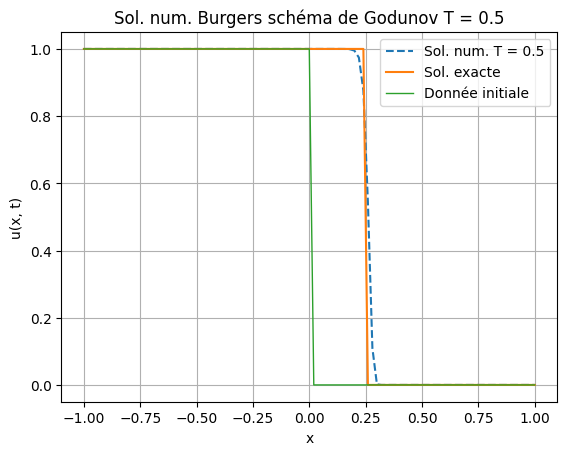

In [7]:
N = 100                                                                                                                                         
X = np.linspace(-1, 1, N+1)

def u_init(x):
    return np.where(x>0, 0., 1.)

def u_exact0(x, t):
    return np.where(x/t < 0.5, 1., 0.)

U0 = u_init(X)
T_vals = [0.5]
dt_init = 0.001

for T in T_vals:
    U = resolution(X, U0, T, dt_init)
    plt.plot(X, U, '--', label=f"Sol. num. T = {T}")

plt.plot(X, u_exact0(X, 0.5), linewidth = 1.5,label="Sol. exacte")
plt.plot(X, U0, linewidth = 1,label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. num. Burgers schéma de Godunov T = {T}")
plt.grid()
plt.legend()
plt.savefig("sol pb riemann Godunov.png")
plt.show()


### Ordre de convergence du schéma de Godunov ###

#### En norme L1 pour les sol. discontinues ####

Nb. iter = 5001


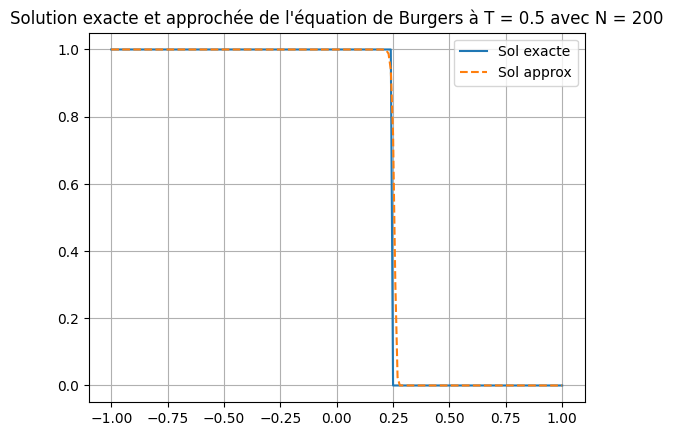

Nb. iter = 5001


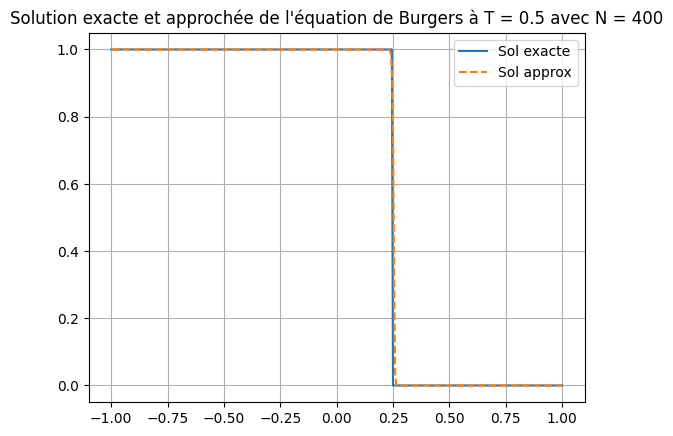

Nb. iter = 5001


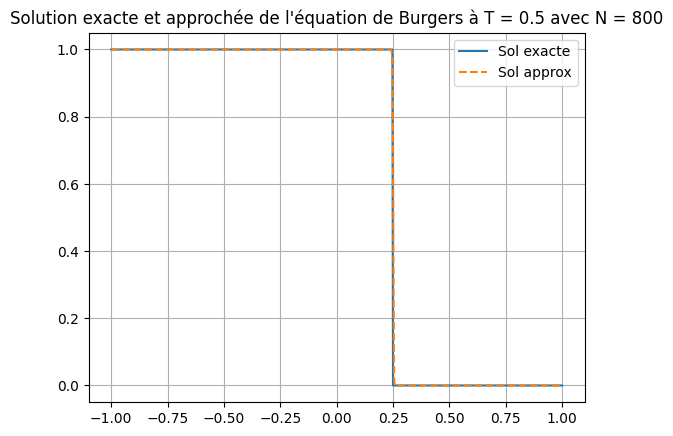

Nb. iter = 5001


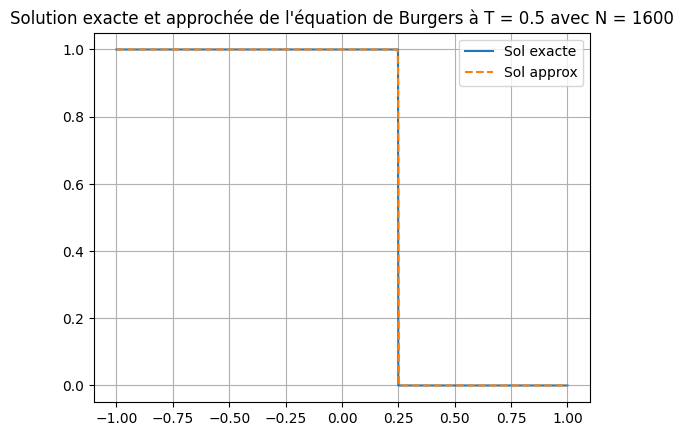

Ordre de convergence en espace du schéma = 0.9954419760872445


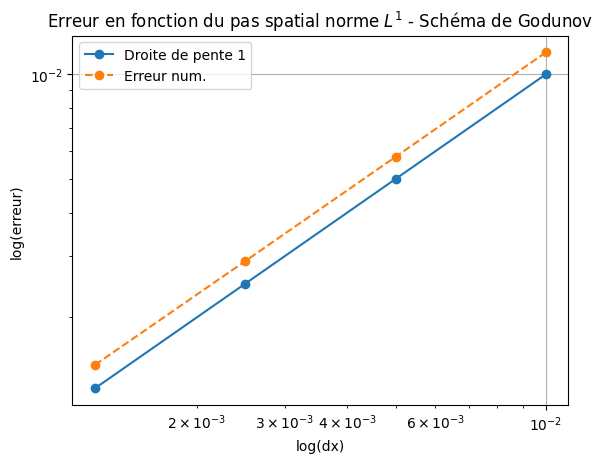

In [87]:
T = 0.5
N_vals = [200, 400, 800, 1600]
erreurs = []
dx_vals = []
dt_init = 1e-4

for N in N_vals:
    XN = np.linspace(-1, 1, N+1)
    dx= XN[1]-XN[0]
    dx_vals.append(dx)
    UexN = u_exact0(XN, T)
    UN = resolution(XN, u_init(XN), T, dt_init)
    plt.plot(XN, UexN, label="Sol exacte")
    plt.plot(XN, UN, '--', label="Sol approx")
    plt.title(f"Solution exacte et approchée de l'équation de Burgers à T = {T} avec N = {N}")
    plt.legend()
    plt.grid()
    plt.show()
    err = np.sum(np.abs(UN - UexN))*dx #attention utilisé la norme L1 pour des solutions discontinues
    erreurs.append(err)

log_dx = np.log(dx_vals)
log_erreurs = np.log(erreurs)
pente, _ = np.polyfit(log_dx, log_erreurs, 1)
print("Ordre de convergence en espace du schéma =", pente)

plt.loglog(dx_vals, dx_vals, 'o-', label ="Droite de pente 1")
plt.loglog(dx_vals, erreurs, 'o--', label ="Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^1$ - Schéma de Godunov")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.savefig("ordre godunov.png")
plt.show()

In [88]:
print(erreurs)

[np.float64(0.011564870958342896), np.float64(0.005789869601492855), np.float64(0.0029026367159227964), np.float64(0.0014596201322200407)]


In [89]:
print(erreurs[-2]/erreurs[-1]) #OKK

1.9886247468428437


#### En norme $L^{\infty}$ (sol. régulière) ####

Nb. iter = 5001


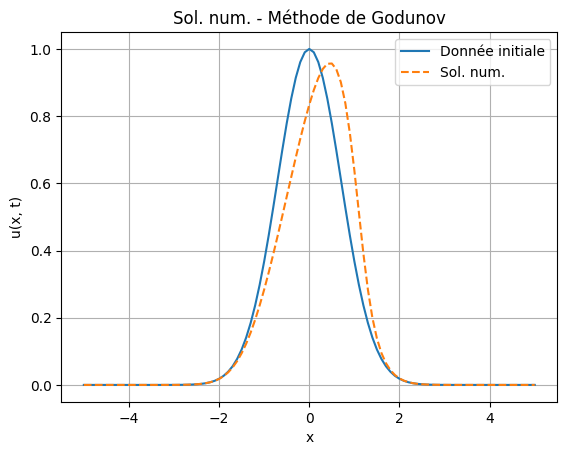

L'intégrale de u_init_reg sur [-5, 5] est : 1.7724538509027912
L'intégrale de la solution numérique su schéma Lax-Wendroff (trapèzes) est : 1.772453850904914


/tmp/ipykernel_9721/1704740811.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integ = np.trapz(u, x)


In [ ]:
def u_init_reg(x):
    return np.exp(-x**2)

T = 0.5 #temps avant l'apparition de choc pour faire l'étude en norme L infinie
N = 100
dt = 1e-2
x = np.linspace(-5, 5, N+1)
u0_reg = u_init_reg(x)
u = resolution(x, u0_reg, T, dt_init)
plt.plot(x, u0_reg, label="Donnée initiale")
plt.plot(x, u, '--', label="Sol. num.")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title("Sol. num. - Méthode de Godunov")
plt.legend()
plt.grid()
plt.show()

# vérification de la conservation de la masse (OKKK.)

result, _ = quad(u_init_reg, -5, 5) #e calcule l'integrale de la donnée initiale sur [-5, 5] (juste par curiosité)
print(f"L'intégrale de u_init_reg sur [-5, 5] est : {result}")

integ = np.trapz(u, x)
print(f"L'intégrale de la solution numérique du schéma Godunov (trapèzes) est : {integ}") #on a bien la préservation de la masse pour le schéma de Godunov

In [15]:
# je prends u_exact = exp(-(x-t)**2), solution analytique (fabriquée)
def u_exact(x, t):
    return np.exp(-(x-t)**2)
def f(x, t):    
    return 2*(x-t)*np.exp(-(x-t)**2)*(1-np.exp(-(x-t)**2))

In [92]:
def resolution_conv(f, x, u0, T, dt_init):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.9*dx/umax)#CFL = 0.9

        u_new = np.copy(u)

        for i in range(1, N-1):
            f_d = flux_godunov(u[i], u[i+1])
            f_g = flux_godunov(u[i-1], u[i])
            u_new[i] = u[i] - dt/dx*(f_d - f_g)
        
        u_new[0] = u_new[1]
        u_new[-1] = u_new[-2]
        u_new = u_new + dt*f(x, t)
        u[:] = u_new
        k+=1
        t+= dt

        # if t+dt>T:
        #     t = T-dt
    print(f"Nb. iter = {k}")
    return u

Nb. iter = 500


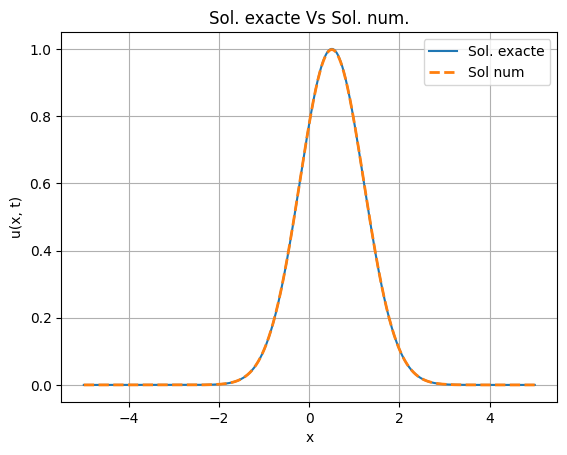

In [93]:
T = 0.5
N= 2000
x = np.linspace(-5, 5, N+1)
dt = 1e-3
u0 = u_exact(x, 0)
u = resolution_conv(f, x, u0, T, dt)
plt.plot(x, u_exact(x, T), label = "Sol. exacte")
plt.plot(x, u,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. exacte Vs Sol. num.")
plt.legend()
plt.grid()
plt.show()

Nb. iter = 500
Nb. iter = 500
Nb. iter = 500
Nb. iter = 500
Ordre de convergence estimé avec dt = 0.001 : 0.97


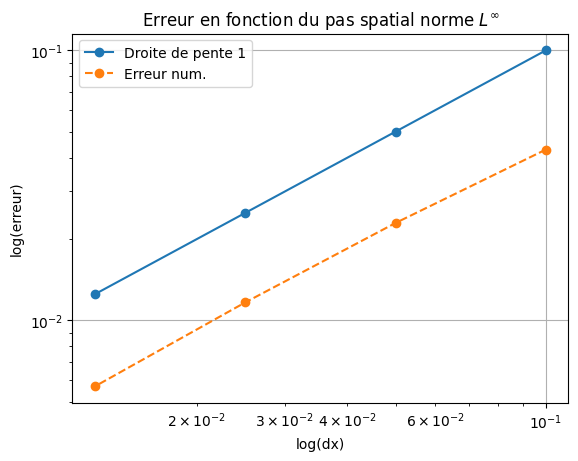

In [94]:
N_vals = [100, 200, 400, 800]

dx_vals_N = []

dt = 1e-3
erreurs_N = []

for N in N_vals:
    x = np.linspace(-5, 5, N+1)
    dx = x[1]-x[0]
    dx_vals_N.append(dx)
    u0 = u_exact(x, 0.)
    un = resolution_conv(f, x, u0, T, dt)
    u_exN = u_exact(x, T)
    err = np.linalg.norm(u_exN - un, np.inf)
    erreurs_N.append(err)



log_erreurs_N = np.log(erreurs_N)
log_dx = np.log(dx_vals_N)

pente1, _ = np.polyfit(log_dx, log_erreurs_N, 1)

print(f"Ordre de convergence estimé avec dt = {dt} : {pente1:.2f}")



plt.loglog(dx_vals_N, dx_vals_N, 'o-', label ="Droite de pente 1")
plt.loglog(dx_vals_N, erreurs_N, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.show()

In [95]:
print("erreurs_dt1", erreurs_N)

erreurs_dt1 [np.float64(0.04291040705569271), np.float64(0.02294161607026257), np.float64(0.011651754015005955), np.float64(0.005694608724353678)]


In [96]:
print(erreurs_N[-2]/erreurs_N[-1])

2.046102652351834


### Schéma MUSCL (Monotone Upwind Scheme for Conservative Laws) ###

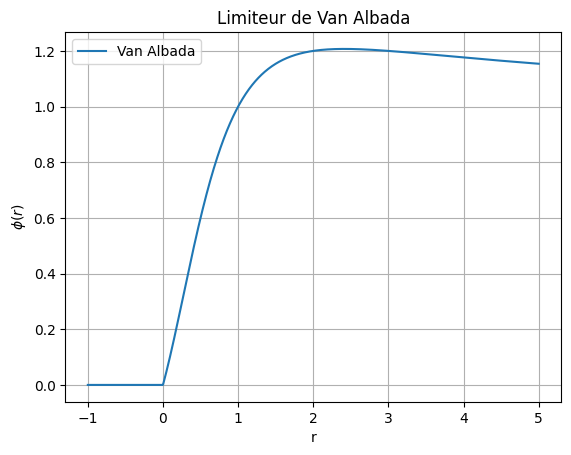

In [19]:
def phi1(r):#Limiteur de Van Albada
    return np.where(r>0, (r**2+r)/(r**2+1), 0)

r = np.linspace(-1, 5, 1000)
plt.plot(r, phi1(r), label = "Van Albada")
plt.xlabel("r")
plt.ylabel(r"$\phi(r)$")
plt.title("Limiteur de Van Albada")
plt.grid()
plt.legend()
plt.savefig("Van_Albada.png")
plt.show()

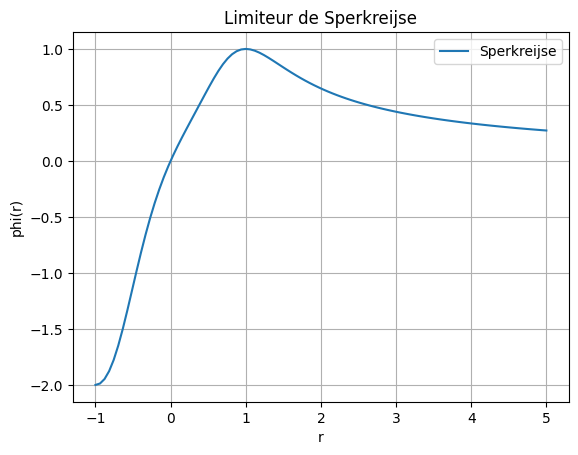

In [98]:
def phi2(r):#Limiteur de Spekreijse
    return (3*r**3 -2*r**2 +3*r)/(2*r**4 + 2)

r = np.linspace(-1, 5, 100)
plt.plot(r, phi2(r), label = "Sperkreijse")
plt.xlabel("r")
plt.ylabel("phi(r)")
plt.title("Limiteur de Sperkreijse")
plt.grid()
plt.legend()
plt.show()

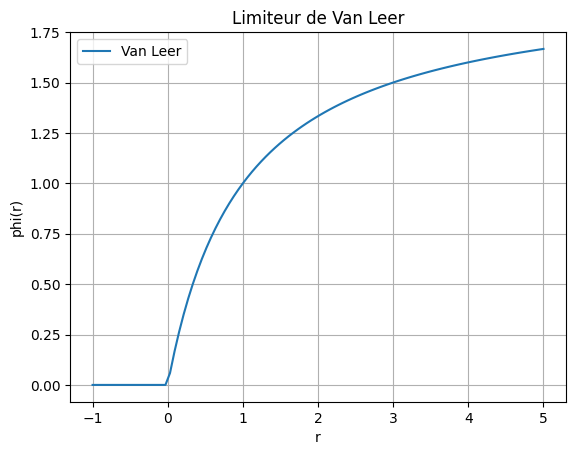

In [99]:
def phi3(r):#Limiteur de Van Leer
    return (r+ np.abs(r))/(1+np.abs(r))

r = np.linspace(-1, 5, 100)
plt.plot(r, phi3(r), label = "Van Leer")
plt.xlabel("r")
plt.ylabel("phi(r)")
plt.title("Limiteur de Van Leer")
plt.grid()
plt.legend()
plt.show()

In [8]:
def muscl_reconstruction(u, beta):
    N = len(u)
    ul = np.zeros(N)
    ur = np.zeros(N)
    for i in range(1, N-2):
        delta_p = u[i+1] - u[i]
        delta_m = u[i] - u[i-1]
        delta_pp = u[i+2] - u[i+1]

        ul[i] = u[i] + 0.25*((1-beta)*delta_p +(1+beta)*delta_m)
        ur[i] = u[i+1] - 0.25*((1-beta)*delta_pp + (1+beta)*delta_p)
    
    #cdt aux bords    
    ul[N-2] = u[N-2]
    ur[N-2] = u[N-1]
    ul[N-1] = u[N-1]
    ur[N-1] = u[N-1]

    # bords extrêmes
    ul[0] = u[0]
    ur[0] = u[1]
    ul[-1] = u[-1]
    ur[-1] = u[-1]

    return ul, ur

In [9]:
def muscl_reconstruction_periodic(u, beta):
    N = len(u)
    
    # Extensions périodiques (ghost cells)
    u_ext = np.concatenate([u[-2:], u, u[:2]])  # u[-2], u[-1], u[0], ..., u[N-1], u[0], u[1]

    # Indices décalés pour faciliter la lecture
    u_m2 = u_ext[0:N]     # u[i-2]
    u_m1 = u_ext[1:N+1]   # u[i-1]
    u_0  = u_ext[2:N+2]   # u[i]
    u_p1 = u_ext[3:N+3]   # u[i+1]
    u_p2 = u_ext[4:N+4]   # u[i+2]

    delta_m = u_0 - u_m1
    delta_p = u_p1 - u_0
    delta_pp = u_p2 - u_p1

    ul = u_0 + 0.25 * ((1 - beta) * delta_p + (1 + beta) * delta_m)
    ur = u_p1 - 0.25 * ((1 - beta) * delta_pp + (1 + beta) * delta_p)

    return ul, ur


In [10]:
def solve(x, u0, T, dt_init, beta):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.9*dx/umax)#CFL = 0.9
        if t+dt>T:
            dt = T-t

        #####Etape 1 de RK
        ul, ur = muscl_reconstruction(u, beta)
        u_star = np.zeros_like(u)
        
        phi = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(phi[1:] - phi[:-1])

        #cdt aux bords (Neumann)
        u_star[0] = u_star[1]
        u_star[-1] = u_star[-2]

        ######Étape 2 de RK
        ul_star, ur_star = muscl_reconstruction(u_star, beta)
        phi_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u[1:-1] = u[1:-1] - (dt/dx)*(phi_star[1:] - phi_star[:-1])

        #cdt aux bords (Neumann)
        u[0] = u[1]
        u[-1] = u[-2]

        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

Nb. iter = 500
Nb. iter = 500


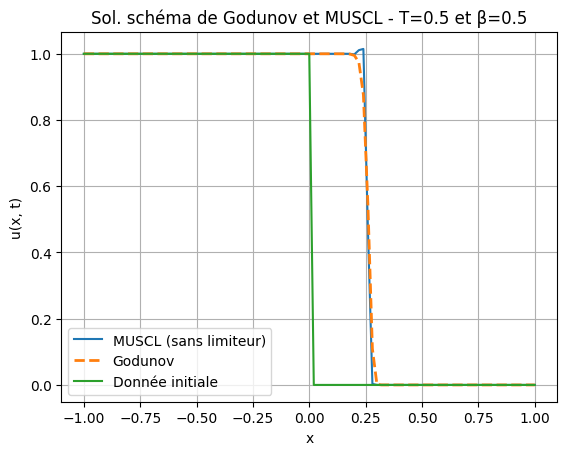

In [103]:
N = 100                                                                                                              
X = np.linspace(-1, 1, N+1)

U0 = u_init(X)
T = 0.5
dt_init = 1e-3
beta = 1./2  #beta = 1 schéma centré


U_muscl = solve(X, U0, T, dt_init, beta)
U_godunov = resolution(X, U0, T, dt_init)
plt.plot(X, U_muscl, '-', label=f"MUSCL (sans limiteur)")
plt.plot(X, U_godunov, '--', linewidth = 2, label=f"Godunov")
plt.plot(X, U0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. schéma de Godunov et MUSCL - T={T} et β={beta}")
plt.grid()
plt.legend()
plt.savefig("Muscl non limite.png")
plt.show()


### Étude de l'ordre de convergence du schéma (MUSCL sans limiteur) ###

In [279]:
def solve_conv(f, x, u0, T, dt_init, beta):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL = 0.9
        if t+dt>T:
            dt = T-t

        #####Etape 1 de RK
        ul, ur = muscl_reconstruction(u, beta)
        u_star = np.zeros_like(u)
        
        phi = np.array([flux_godunov(ul[i], ur[i]) for i in range(N)])
        u_star[1:-1] = u[1:-1] - 0.5*(dt/dx)*(phi[1:-1] - phi[0:-2]) + 0.5*dt*f(x[1:-1], t)

        #cdt aux bords per.
        u_star[0] = u_star[-1]

        ######Étape 2 de RK
        u_new = np.copy(u)
        ul_star, ur_star = muscl_reconstruction(u_star, beta)
        phi_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N)])

        u_new[1:-1] = u[1:-1] - (dt/dx)*(phi_star[1:-1] - phi_star[0:-2]) + dt*f(x[1:-1], t+0.5*dt)

        #cdt aux bords per.
        u_new[0] = u_new[-1]

        u = u_new
        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

In [280]:
def solve_conv_heun(f, x, u0, T, dt_init, beta, adaptatif=True):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        if adaptatif:
            dt = min(dt_init, 0.5*dx/umax)#CFL
        else:
            dt = dt_init

            
        if t+dt>T:
            dt = T-t

        #####Etape 1 de Heun
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.zeros_like(u)
        
        phi = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (dt/dx)*(phi[1:] - phi[:-1]) + dt*f(x[1:-1], t)

        #cdt aux bords period.
        u_star[0] = u_star[-1]

        ######Étape 2 de Heun
        u_new = np.copy(u)
        ul_star, ur_star = muscl_reconstruction_periodic(u_star, beta)
        phi_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u_new[1:-1] = u[1:-1]  - 0.5*(dt/dx)*(phi[1:] - phi[:-1]) + 0.5*dt*f(x[1:-1], t) - 0.5*(dt/dx)*(phi_star[1:] - phi_star[:-1]) + 0.5*dt*f(x[1:-1], t+dt)

        #cdt aux bords period.
        u_new[0] = u_new[-1]

        u = u_new
        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

Nb. iter = 500


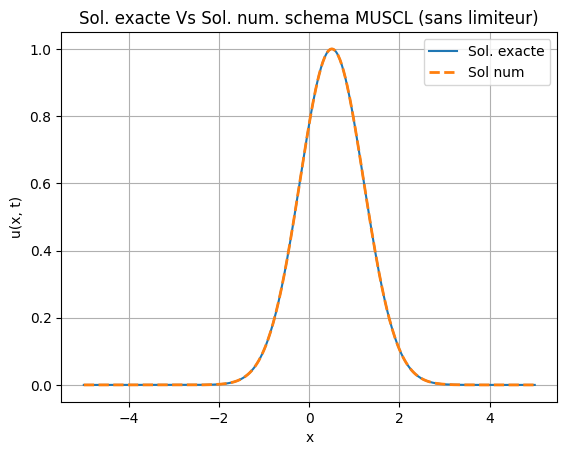

In [281]:
T = 0.5
N= 500
x = np.linspace(-5, 5, N+1)
dt = 1e-3
u0 = u_exact(x, 0)
beta = 1./2
u= solve_conv(f, x, u0, T, dt, beta)
plt.plot(x, u_exact(x, T), label = "Sol. exacte")
plt.plot(x, u,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. exacte Vs Sol. num. schema MUSCL (sans limiteur)")
plt.legend()
plt.grid()
plt.show()

Nb. iter = 5001
Nb. iter = 5001
Nb. iter = 5001
Nb. iter = 5001
Ordre de convergence estimé avec dt = 0.0001 : 1.95


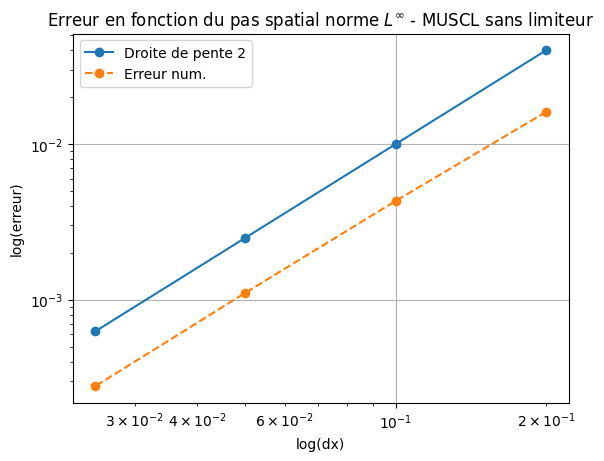

In [282]:
T = 0.5
dt = 1e-4
Nvals = [50, 100, 200, 400]

dxvals = []
errors = []

for N in Nvals:
    x = np.linspace(-5, 5, N+1)
    dx = x[1]-x[0]
    dxvals.append(dx)
    u0 = u_exact(x, 0.)
    un = solve_conv(f, x, u0, T, dt, beta)
    u_exN = u_exact(x, T)
    err1 = np.linalg.norm(u_exN - un, np.inf)
    errors.append(err1)


logErrors = np.log(errors)
logdx = np.log(dxvals)

pente2, _ = np.polyfit(logdx, logErrors, 1)

print(f"Ordre de convergence estimé avec dt = {dt} : {pente2:.2f}")



plt.loglog(dxvals, np.array(dxvals)**2, 'o-', label ="Droite de pente 2")
plt.loglog(dxvals, errors, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$ - MUSCL sans limiteur")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
#plt.savefig("ordre muscl non limite.png")
plt.show()

Ordre en temps

Nb. iter = 80
Nb. iter = 800
Nb. iter = 1601
Ordre de convergence estimé: 0.04
---------------test--------------------------


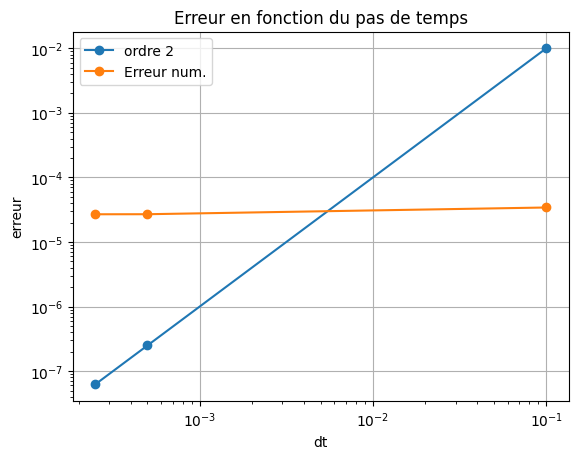

In [284]:
T= 0.4
beta = 1/3.
N = 1000
x = np.linspace(-5, 5, N+1)
u_ex = u_exact(x, T)
u0 = u_exact(x, 0.)
dt_vals = [1e-1, 1e-3/2, 1e-3/4]

####

vals_erreurs = []

for dt in dt_vals:
    udt = solve_conv(f, x, u0, T, dt, beta)
    err = np.linalg.norm(u_ex - udt, np.inf)

    vals_erreurs.append(err)


log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs)

pente, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt**2, marker ='o', label = "ordre 2")
plt.loglog(dt, vals_erreurs, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

In [234]:
print(vals_erreurs[-2]/vals_erreurs[-1])

1.0000220693415613


!!!! Voir la solution à ce problème d'ordre de convergence dans le fichier ordre_temps_rk.ipynb

On voit toujours des oscillations (plus ou moins fortes dépendant de la valeur du paramètre de décentrage $\beta$), ce schéma n'est pas TVD bien que d'ordre élevé. On adjoint des limiteurs de pente afin de rendre TVD le schéma tout en conservant sa précision.


In [11]:
def muscl_reconstruction_limite(u, beta, phi):
    N = len(u)
    ul = np.zeros(N)
    ur = np.zeros(N)
    for i in range(1, N-2):
        delta_p = u[i+1] - u[i]
        delta_m = u[i] - u[i-1]
        delta_pp = u[i+2] - u[i+1]
        r_il = delta_m/(delta_p+1e-10) #on évite de diviser par 0
        r_ir = delta_p/(delta_pp+1e-10)
        phi_il = phi(r_il)
        phi_ir = phi(r_ir)

        ul[i] = u[i] + phi_il*0.25*((1-beta)*delta_p + (1+beta)*delta_m)
        ur[i] = u[i+1] - phi_ir*0.25*((1-beta)*delta_pp + (1+beta)*delta_p)
    
    #cdt aux bords
    delta_p = u[-1] - u[-2]
    delta_m = u[-2] - u[-3]
    delta_pp = u[0] - u[-1]
    r_l = delta_m/(delta_p+1e-10) #on évite de diviser par 0
    r_r = delta_p/(delta_pp+1e-10)
    phi_l = phi(r_l)
    phi_r = phi(r_r)
    ul[N-2] = u[N-2] + phi_l*0.25*((1-beta)*delta_p +(1+beta)*delta_m)
    ur[N-2] = u[N-1] - phi_r*0.25*((1-beta)*delta_pp + (1+beta)*delta_p)
    ul[N-1] = u[N-1]
    ur[N-1] = u[N-1]

    # bords extrêmes
    ul[0] = u[0]
    ur[0] = u[0]
    ul[-1] = u[-1]
    ur[-1] = u[-1]

    return ul, ur

In [12]:
def beta_schema_limite(x, u0, T, dt_init, beta, phi):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.8*dx/umax)#CFL = 0.9
        if t+dt>T:
            dt = T-t

        #####Etape 1 de RK 2
        ul, ur = muscl_reconstruction_limite(u, beta, phi)
        u_star = np.zeros_like(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N)])
        u_star[1:-1] = u[1:-1] - 0.5*(dt/dx)*(flux[1:-1] - flux[0:-2])

        #cdt aux bords (Neumann)
        u_star[0] = u_star[1]
        u_star[-1] = u_star[-2]

        ######Étape 2 de RK 2
        ul_star, ur_star = muscl_reconstruction_limite(u_star, beta, phi)
        flux_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N)])

        u[1:-1] = u[1:-1] - (dt/dx)*(flux_star[1:-1] - flux_star[0:-2])

        #cdt aux bords (Neumann)
        u[0] = u[1]
        u[-1] = u[-2]

        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

In [13]:
def minmod(r):
    return np.maximum(0, np.minimum(1, r))

Nb. iter = 500
Nb. iter = 500


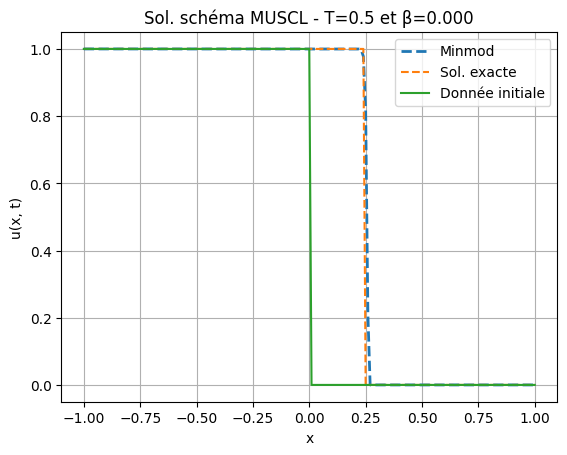

In [115]:
N = 200                                                                                                          
X = np.linspace(-1, 1, N+1)

U0 = u_init(X)
T = 0.5
dt_init = 1e-3
beta = 0  #beta = 1 schéma centré


U_va = beta_schema_limite(X, U0, T, dt_init, beta, phi1)
U_sp = beta_schema_limite(X, U0, T, dt_init, beta, minmod)
#U_vl = beta_schema_limite(X, U0, T, dt_init, beta, phi3)

#plt.plot(X, U_va, '--', linewidth = 1.5, label=f"Van Albada")
plt.plot(X, U_sp, '--', linewidth = 2, label=f"Minmod")
plt.plot(X, u_exact0(X, T),'--', label = "Sol. exacte")
#plt.plot(X, U_vl, '-', linewidth = 0.75, label=f"Van Leer")

plt.plot(X, U0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. schéma MUSCL - T={T} et β={beta:.3f}")
plt.grid()
plt.legend()
plt.savefig('result minmod.png')
plt.show()


### Étude de l'ordre de convergence du schéma MUSCL avec limiteur de pente (Van Albada) ###

In [17]:
def beta_schema_limite_conv(f, x, u0, T, dt_init, beta, phi):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.1*dx/umax)#CFL = 0.9
        if t+dt>T:
            dt = T-t

        #####Etape 1 de RK 2
        ul, ur = muscl_reconstruction_limite(u, beta, phi1)
        u_star = np.zeros_like(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:-1] - flux[0:-2]) + 0.5*dt*f(x[1:-1], t)

        #cdt aux bords (Neumann)
        u_star[0] = u_star[1]
        u_star[-1] = u_star[-2]

        ######Étape 2 de RK 2
        ul_star, ur_star = muscl_reconstruction_limite(u_star, beta, phi)
        flux_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N)])

        u[1:-1] = u[1:-1] - (dt/dx)*(flux_star[1:-1] - flux_star[0:-2]) + dt*f(x[1:-1], t+dt)

        #cdt aux bords (Neumann)
        u[0] = u[1]
        u[-1] = u[-2]

        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

Nb. iter = 500


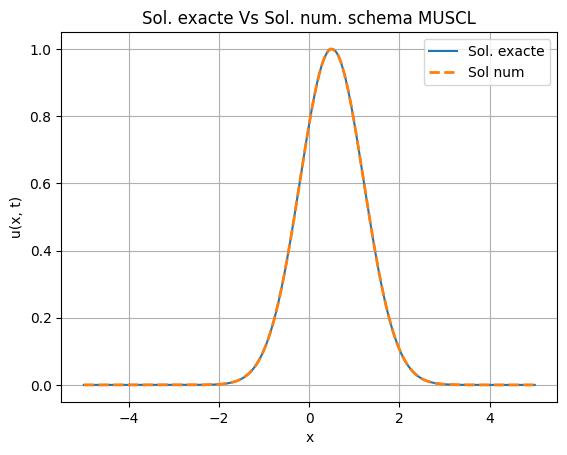

In [117]:
T = 0.5
N= 500
x = np.linspace(-5, 5, N+1)
dt = 1e-3
u0 = u_exact(x, 0)
beta = 0
u = beta_schema_limite_conv(f, x, u0, T, dt_init, beta, phi1)
plt.plot(x, u_exact(x, T), label = "Sol. exacte")
plt.plot(x, u,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. exacte Vs Sol. num. schema MUSCL")
plt.legend()
plt.grid()
plt.show()

In [118]:
def phi_charm(r):#CHARM limiteur
    return np.where(r>0, (r*(3*r+1))/(r+1)**2, 0)

Blocage !!!

In [119]:
def superbee(r):
    return np.maximum(0, np.minimum(2, np.minimum(1, r)))

Nb. iter = 500
Nb. iter = 500


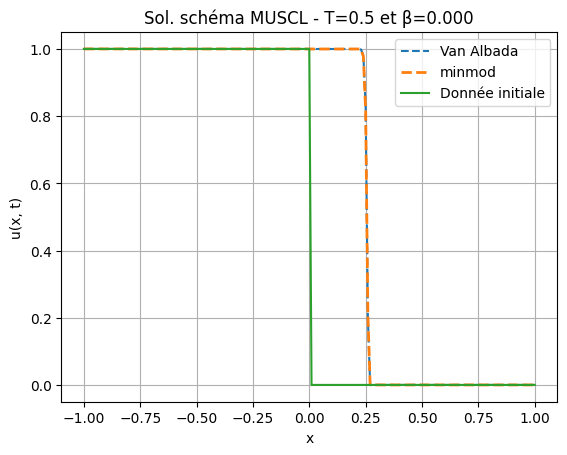

In [120]:
N = 200                                                                                                          
X = np.linspace(-1, 1, N+1)

U0 = u_init(X)
T = 0.5
dt_init = 1e-3
beta = 0  #beta = 1 schéma centré


U_va = beta_schema_limite(X, U0, T, dt_init, beta, phi1)
U_mm = beta_schema_limite(X, U0, T, dt_init, beta, minmod)
#U_vl = beta_schema_limite(X, U0, T, dt_init, beta, phi3)

plt.plot(X, U_va, '--', linewidth = 1.5, label=f"Van Albada")
plt.plot(X, U_mm, '--', linewidth = 2, label=f"minmod")
#plt.plot(X, U_vl, '-', linewidth = 0.75, label=f"Van Leer")

plt.plot(X, U0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. schéma MUSCL - T={T} et β={beta:.3f}")
plt.grid()
plt.legend()
plt.savefig('van albada et minmod.png')
plt.show()


In [131]:
def phi_mc(r):# limiteur monotonized centered
    return np.maximum(0., np.minimum(2*r, np.minimum(0.5*(1 + r), 2.)))

def phi_v(r):
    return (r**2+2*r)/(r**2+ r + 2)

Nb. iter = 400
Nb. iter = 441
Nb. iter = 881
Ordre de convergence estimé avec dt = 0.001 : 1.55


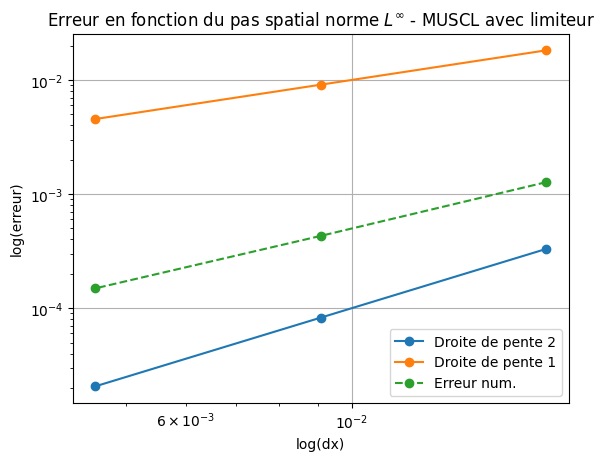

In [20]:
beta = 1/3
T = 0.4
dt_1 = 1e-3
N_vals1 = [550, 1100, 2200]
beta =1/3.
dxvals1 = []
erreurs1 = []

for N in N_vals1:
    x = np.linspace(-5, 5, N+1)
    dx = x[1]-x[0]
    dxvals1.append(dx)
    u0 = u_exact(x, 0.)
    un = beta_schema_limite_conv(f, x, u0, T, dt_1, beta, phi1)
    u_exN = u_exact(x, T)
    err1 = np.linalg.norm(u_exN - un, np.inf)
    erreurs1.append(err1)



logErreurs1 = np.log(erreurs1)
log_dx = np.log(dxvals1)

pente, _ = np.polyfit(log_dx, logErreurs1, 1)
    
print(f"Ordre de convergence estimé avec dt = {dt_1} : {pente:.2f}")



plt.loglog(dxvals1, np.array(dxvals1)**2, 'o-', label ="Droite de pente 2")
plt.loglog(dxvals1, np.array(dxvals1), 'o-', label ="Droite de pente 1")
plt.loglog(dxvals1, erreurs1, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$ - MUSCL avec limiteur")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.savefig("ordre muscl limite")
plt.show()

In [146]:
print("erreurs1 ", erreurs1)

erreurs1  [np.float64(0.0012713641564890965), np.float64(0.000430011518205653), np.float64(0.00014921309227788893)]


Résolution de l'équation de Burgers avec viscosité par la méthode de splitting de strang

In [21]:
def impicit_diffusion(u, dx, dt, nu):
    #Matrice pour la diffusion
    N = len(u)
    r = nu*dt/dx**2
    diag = (1+2*r)*np.ones(N)
    hors_diag = -r*np.ones(N-1)
    A = sp.diags([hors_diag, diag, hors_diag], [-1, 0, 1], shape=(N, N), format='csr')
    A[0, -1]=-r #cdt aux bords
    A[-1, 0]= -r #cdt aux bords

    return spla.spsolve(A, u)

In [22]:
def lie(x, u0, T, dt_init, beta, nu):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.copy(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (dt/dx)*(flux[1:] - flux[:-1])

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)  -  implicite
        u_new = impicit_diffusion(u_star, dx, dt, nu)

        u = u_new
        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

In [23]:
def u_initial(x):
    return np.sin(np.pi*x)

/home/sonko/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter = 400


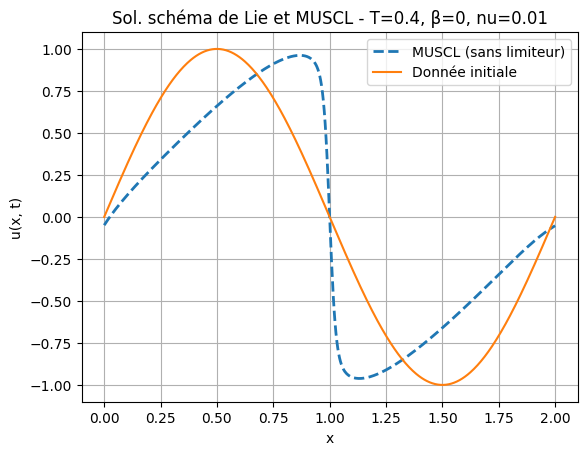

In [22]:
N = 500                                                                                                              
X = np.linspace(0, 2, N+1)

u0 = u_initial(X)
T = 0.4
dt = 1e-3
beta = 0
nu = 1e-2
u_lie = lie(X, u0, T, dt, beta, nu)
plt.plot(X, u_lie, '--',linewidth = 2, label=f"MUSCL (sans limiteur)")
plt.plot(X, u0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. schéma de Lie et MUSCL - T={T}, β={beta}, nu={nu}")
plt.grid()
plt.legend()
plt.savefig("Muscl - lie.png")
plt.show()


In [23]:
def strang(x, u0, T, dt_init, beta, nu):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.copy(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1])

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)
        u_star_star = impicit_diffusion(u_star, dx, dt, nu)


        #####Étape 3 de strang (1/2 pas de temps)
        u_new = np.copy(u_star_star)
        ul1, ur1 = muscl_reconstruction_periodic(u_star_star, beta)
        flux_star = np.array([flux_godunov(ul1[i], ur1[i]) for i in range(N-1)])

        u_new[1:-1] = u_star_star[1:-1] - (0.5*dt/dx)*(flux_star[1:] - flux_star[:-1])

        #cdt aux bords periodiques
        u_new[0] = u_new[-1]


        u = u_new
        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

Nb. iter = 200


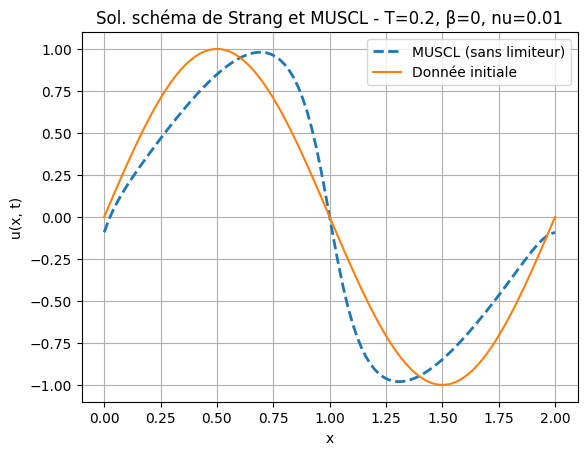

-0.09195119017720749   -0.09195119017720749


In [39]:
N = 100
X = np.linspace(0, 2, N+1)

u0 = u_initial(X)
T = 0.2
dt_init = 1e-3
beta = 0
nu = 1e-2
u_strang = strang(X, u0, T, dt_init, beta, nu)
plt.plot(X, u_strang, '--',linewidth = 2, label=f"MUSCL (sans limiteur)")
plt.plot(X, u0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. schéma de Strang et MUSCL - T={T}, β={beta}, nu={nu}")
plt.grid()
plt.legend()
#plt.savefig("Muscl - strang.png")
plt.show()
print(u_strang[0]," ", u_strang[-1])

### Ordre de convergence des schémas en temps et en espace ###

In [29]:
# je prends u_exact = exp(-(x-t)**2), solution analytique (fabriquée)
def U_ex(x, t):
    return np.exp(-(x-t)**2)

def F(x, t, nu):    
    return np.exp(-(x-t)**2)*(2*(x-t) -2*(x-t)*np.exp(-(x-t)**2) - nu*(-2+4*(x-t)**2))


Pour le splitting de lie

In [27]:
def lie_conv(f, x, u0, T, dt_init, beta, nu):#méthode de splitting de Lie

    N = len(x) 
    u = np.copy(u0)
    dx = x[1]-x[0]


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.copy(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (dt/dx)*(flux[1:] - flux[:-1]) + dt*f(x[1:-1], t, nu)

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape2
        u = impicit_diffusion(u_star, dx, dt, nu)

        k+=1
        t+= dt

    print("Nb. iter = ", k)


    return u


Nb. iter =  400


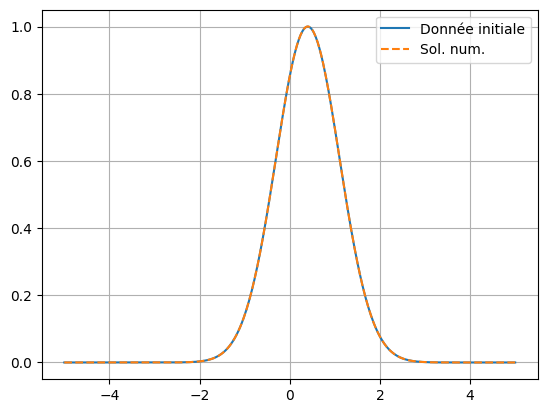

In [28]:
N = 500
x = np.linspace(-5, 5, N+1)
T = 0.4
nu = 1e-2
beta = 0
dt = 1e-3
u_num = lie_conv(F, x, U_ex(x, 0.), T, dt, beta, nu)
plt.plot(x, U_ex(x,T), label="Donnée initiale")
plt.plot(x, u_num, '--', label='Sol. num.')
plt.legend()
plt.grid()
plt.show()

Nb. iter =  4001
Nb. iter =  4001
Nb. iter =  4001
Ordre de convergence en espace Linf (Lie) estimé: 2.02


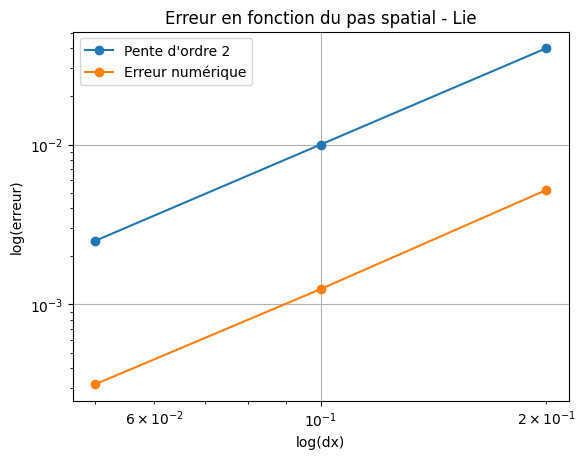

In [29]:
T= 0.4
nu = 1e-2
beta = 0
dt_init = 1e-4


N_values = [50, 100, 200]
vals_erreurLinf = []
dx_vals = []

for N in N_values:
    x = np.linspace(-5, 5, N+1)
    dx = x[1] -x[0]
    u0 = U_ex(x, 0) #condition initiale
    u = lie_conv(F, x, u0, T, dt_init, beta, nu)
    u_e = U_ex(x, T)

    

    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))
    dx_vals.append(dx)


log_dx = np.log(dx_vals)
log_erreurLinf = np.log(vals_erreurLinf)

pente2, intercept2 = np.polyfit(log_dx, log_erreurLinf, 1)
print(f"Ordre de convergence en espace Linf (Lie) estimé: {pente2:.2f}")



# Ajout de la pente d'ordre 2
dx_vals = np.array(dx_vals)
plt.loglog(dx_vals, dx_vals**2, marker='o', label="Pente d'ordre 2")

plt.loglog(dx_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Lie')
plt.legend()
plt.grid()   
plt.show()

In [30]:
print(vals_erreurLinf)

[np.float64(0.005189699205880638), np.float64(0.0012476026112557825), np.float64(0.0003165196730030573)]


/home/sonko/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  400
Nb. iter =  800
Nb. iter =  1601
Ordre de convergence en temps Linf (Lie) estimé: 0.98


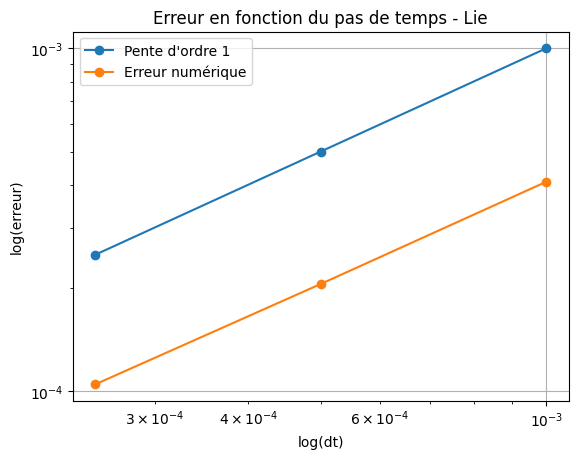

In [31]:
T= 0.4
nu = 0
beta = 0
dt_vals = [1e-3, 1e-3/2, 1e-3/4]
N = 1000
x = np.linspace(-5, 5, N+1)
dx = x[1] -x[0]
u0 = U_ex(x, 0) #condition initiale
u_e = U_ex(x, T)
vals_erreurLinf = []

for dt in dt_vals:
    u = lie_conv(F, x, u0, T, dt, beta, nu)
    
    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))


log_dt = np.log(dt_vals)
log_erreurLinf = np.log(vals_erreurLinf)

pente, intercept = np.polyfit(log_dt, log_erreurLinf, 1)
print(f"Ordre de convergence en temps Linf (Lie) estimé: {pente:.2f}")



# Ajout de la pente d'ordre 1
dt_vals = np.array(dt_vals)
plt.loglog(dt_vals, dt_vals, marker='o', label="Pente d'ordre 1")

plt.loglog(dt_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dt)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas de temps - Lie')
plt.legend()
plt.grid()
plt.savefig("ordre_lie.png")   
plt.show()

Pour le splitting de Strang

In [34]:
def strang_conv1(f, x, u0, T, dt_init, beta, nu):#méthode de splitting de strang

    N = len(x)
    u = np.copy(u0)
    dx = x[1]-x[0]


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction_periodic(u, beta)
        u_star = np.copy(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1]) + 0.5*dt*f(x[1:-1], t+0.5*dt, nu)

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)
        u_star_star = impicit_diffusion(u_star, dx, dt, nu)


        #####Étape 3 de strang (1/2 pas de temps)
        u_new = np.copy(u_star_star)
        ul1, ur1 = muscl_reconstruction_periodic(u_star_star, beta)
        flux_star = np.array([flux_godunov(ul1[i], ur1[i]) for i in range(N-1)])

        u_new[1:-1] = u_star_star[1:-1] - (0.5*dt/dx)*(flux_star[1:] - flux_star[:-1]) + 0.5*dt*f(x[1:-1], t+0.5*dt, nu)

        #cdt aux bords periodiques
        u_new[0] = u_new[-1]


        u = u_new
        k+=1
        t+= dt

    print("Nb. iter = ", k)


    return u


In [33]:
def strang_conv2(x, u0, T, dt_init, beta, nu):#méthode de splitting de strang --- j'ai enlevé le terme source ici

    N = len(x)
    u = np.copy(u0)
    dx = x[1]-x[0]


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL
        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction(u, beta)
        u_star = np.copy(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:-1] - flux[0:-2])

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)
        u_star_star = impicit_diffusion(u_star, dx, dt, nu)


        #####Étape 3 de strang (1/2 pas de temps)
        u_new = np.copy(u_star_star)
        ul1, ur1 = muscl_reconstruction(u_star_star, beta)
        flux_star = np.array([flux_godunov(ul1[i], ur1[i]) for i in range(N-1)])

        u_new[1:-1] = u_star_star[1:-1] - (0.5*dt/dx)*(flux_star[1:-1] - flux_star[0:-2])

        #cdt aux bords periodiques
        u_new[0] = u_new[-1]


        u = u_new
        k+=1
        t+= dt

    print("Nb. iter = ", k)


    return u


In [297]:
# N = 50
# x = np.linspace(-5, 5, N+1)
# T = 0.4
# nu = 0
# beta = 0
# dt = 1e-3
# u_num = strang_conv(F, x, U_ex(x, 0.), T, dt, beta, nu)
# plt.plot(x, U_ex(x,T), label="Sol. ex.")
# plt.plot(x, u_num, '--', label='Sol. num.')
# plt.legend()
# plt.grid()
# plt.show()

/home/sonko/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  4001
Nb. iter =  4001
Nb. iter =  4001
Ordre de convergence en espace (strang) estimé: 2.06


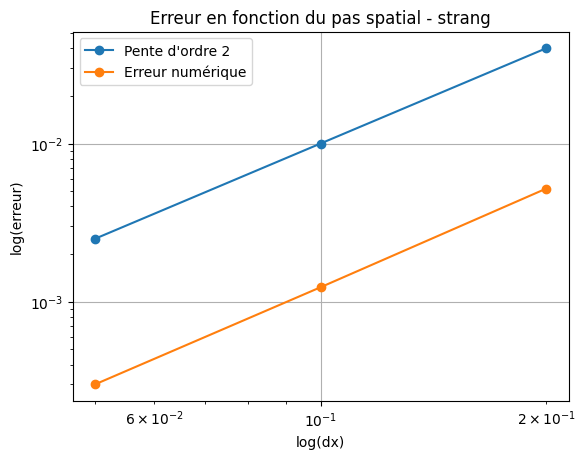

In [35]:
T= 0.4
nu = 1e-2
beta = 0
dt_init = 1e-4

N_values = [50, 100, 200]
vals_erreur_strang = []
dx_vals = []

for N in N_values:
    x = np.linspace(-5, 5, N+1)
    dx = x[1] -x[0]
    u0 = U_ex(x, 0) #condition initiale
    u = strang_conv1(F, x, u0, T, dt_init, beta, nu)
    u_e = U_ex(x, T)

    

    erreur = u - u_e
    vals_erreur_strang.append(np.max(np.abs(erreur)))
    dx_vals.append(dx)


log_dx = np.log(dx_vals)
log_erreur = np.log(vals_erreur_strang)

pente, intercept = np.polyfit(log_dx, log_erreur, 1)
print(f"Ordre de convergence en espace (strang) estimé: {pente:.2f}")



# Ajout de la pente d'ordre 2
dx_vals = np.array(dx_vals)
plt.loglog(dx_vals, dx_vals**2, marker='o', label="Pente d'ordre 2")

plt.loglog(dx_vals, vals_erreur_strang, marker='o', label="Erreur numérique")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - strang')
plt.legend()
plt.grid()   
plt.show()

In [ ]:
T= 0.4
nu = 1e-2
beta = 1/3.
dt_vals = [1e-3, 1e-3/2, 1e-3/4, 1e-3/8]
N = 5000
x = np.linspace(-5, 5, N+1)
dx = x[1] -x[0]
u0 = U_ex(x, 0) #condition initiale
u_e = U_ex(x, T)
vals_erreur_strang = []

for dt in dt_vals:
    u = strang_conv1(F, x, u0, T, dt, beta, nu)
    
    erreur = u - u_e
    vals_erreur_strang.append(np.max(np.abs(erreur)))


log_dt = np.log(dt_vals)
log_erreur_strang = np.log(vals_erreur_strang)

pente, intercept = np.polyfit(log_dt, log_erreur_strang, 1)
print(f"Ordre de convergence en temps estimé: {pente:.2f}")



# Ajout de la pente d'ordre 2
dt_vals = np.array(dt_vals)
plt.loglog(dt_vals, dt_vals**2, marker='o', label="Pente d'ordre 2")
plt.loglog(dt_vals, dt_vals, marker='o', label="Pente d'ordre 1")

plt.loglog(dt_vals, vals_erreur_strang, '--', marker='o', label="Erreur num.")
plt.xlabel("log(dt)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas de temps - strang')
plt.legend()
plt.grid()   
plt.show()

/home/sonko/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  401


Dans le cas ci dessus je n'obtiens pas l'ordre de convergence en temps attendu pour la méthode de splitting de strang.
Essayons de calculer l'ordre de convergence autrement, en se donnant une solution de référence à la place de la solution exacte. (plus besoin du terme source)

/home/sonko/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  40000


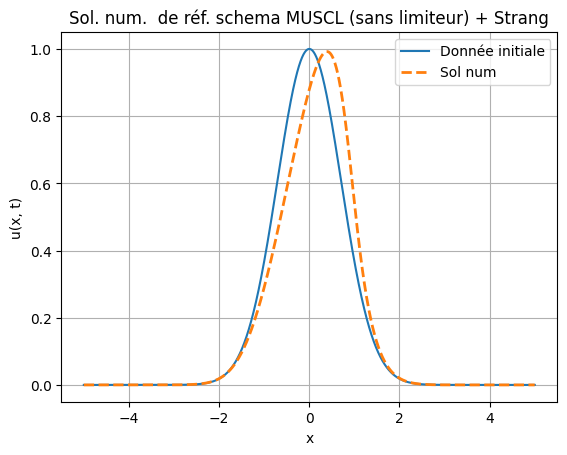

In [295]:
T= 0.4
nu = 1e-2
beta = 1/3.
N_ref = 10000
x_ref = np.linspace(-5, 5, N_ref+1)
u0 = U_ex(x_ref, 0)
dt_ref = 1e-5
u_ref = strang_conv(x_ref, u0, T, dt_ref, beta, nu) #solution de référence
plt.plot(x_ref, u0, label = "Donnée initiale")
plt.plot(x_ref, u_ref,'--', linewidth = 2, label = "Sol num")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. num.  de réf. schema MUSCL (sans limiteur) + Strang")
plt.legend()
plt.grid()
plt.show()

Nb. iter =  801
Nb. iter =  1601
Nb. iter =  2401
Nb. iter =  3201
Nb. iter =  4001
Nb. iter =  4801
Nb. iter =  5601
Nb. iter =  6400
Nb. iter =  7201
Ordre de convergence estimé: 1.08
---------------test--------------------------


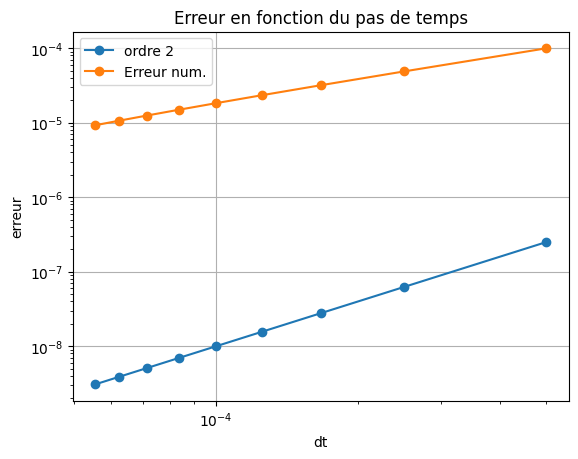

In [296]:
dt_vals = [1e-3/(2*i) for i in range(1, 10)]
#####
u0 = U_ex(x_ref, 0)

erreurs = []

for dt in dt_vals:
    u = strang_conv(x_ref, u0, T, dt, beta, nu)
    err = np.linalg.norm(u_ref - u, np.inf)

    erreurs.append(err)


log_dt = np.log(dt_vals)
log_erreurs = np.log(erreurs)

pente, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt**2, marker ='o', label = "ordre 2")
plt.loglog(dt, erreurs, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

!!!Problème sur l'ordre

Autre méthode: calculer l'erreur à chaque step dt (dans la boucle)

In [104]:
def strang_conv2(f, x, u0, T, dt_init, beta, nu):#méthode de splitting de strang

    N = len(x)
    u = np.copy(u0)
    dx = x[1]-x[0]

    erreurs = []

    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations

    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL

        if t+dt>T:
            dt = T-t

        #####Etape 1 de strang (1/2 pas de temps)
        ul, ur = muscl_reconstruction(u, beta)
        u_star = np.copy(u)
        
        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1]) + 0.5*dt*f(x[1:-1], t, nu)

        #cdt aux bords periodiques
        u_star[0] = u_star[-1]

        ######Étape 2 de strang (pas de temps complet)
        u = impicit_diffusion(u_star, dx, dt, nu)


        #####Étape 3 de strang (1/2 pas de temps)
        ul_star, ur_star = muscl_reconstruction(u, beta)
        flux_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux_star[1:] - flux_star[:-1]) + 0.5*dt*f(x[1:-1], t+0.5*dt, nu)

        #cdt aux bords periodiques
        u[0] = u[-1]


        u_ex = U_ex(x, t)
        err = u - u_ex
        erreurs.append(np.linalg.norm(err, ord=1))

        
        k+=1
        t+= dt

    print("Nb. iter = ", k)


    return erreurs

/home/sonko/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Nb. iter =  81
Nb. iter =  160
Nb. iter =  321
Nb. iter =  641
Nb. iter =  1281
Nb. iter =  2560
Nb. iter =  5121
Ordre de convergence estimé: 0.97
---------------test--------------------------


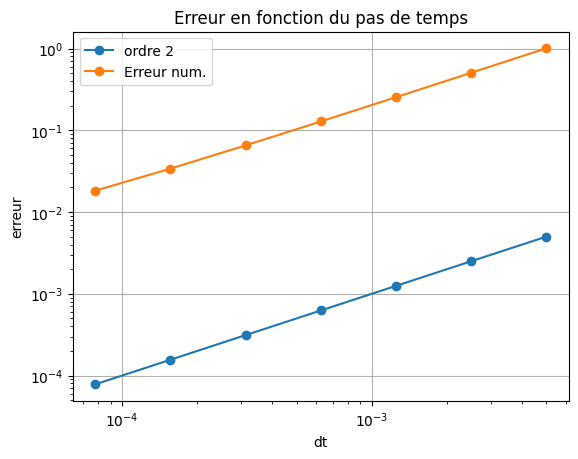

In [105]:
T= 0.4
nu = 1e-2
beta = 1/3.
N = 1000
x = np.linspace(-5, 5, N+1)
u0 = U_ex(x, 0)
dt_vals = [1e-2/2, 1e-2/4, 1e-2/8, 1e-2/16, 1e-2/32, 1e-2/64, 1e-2/128]

####

vals_erreurs = []

for dt in dt_vals:
    err = strang_conv2(F, x, u0, T, dt, beta, nu)

    vals_erreurs.append(np.max(np.abs(err)))


log_dt = np.log(dt_vals)
log_erreurs = np.log(vals_erreurs)

pente, _= np.polyfit(log_dt, log_erreurs, 1)

print(f"Ordre de convergence estimé: {pente:.2f}")
print("---------------test--------------------------")

dt = np.array(dt_vals)
plt.loglog(dt, dt, marker ='o', label = "ordre 2")
plt.loglog(dt, vals_erreurs, marker='o', label="Erreur num.")

plt.title("Erreur en fonction du pas de temps")
plt.xlabel('dt')
plt.ylabel('erreur')
plt.legend()
plt.grid(True)
plt.show()

Ça ne nous donne pas l'ordre en temps attendu pour la méthode de strang, ce qu'on a obtenu avec cette méthode est similaire au cas où on faisait la comparaison à l'instant T de la solution exacte avec des solutions numériques calculées avec des pas de temps différents (dt, dt/2, ...)